Dataset Shape: (614, 13)

Missing Values:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Best K Value: 9
Best Validation Accuracy: 85.37 %

KNN MODEL RESULTS
Accuracy: 85.37 %

Confusion Matrix:
[[23 15]
 [ 3 82]]


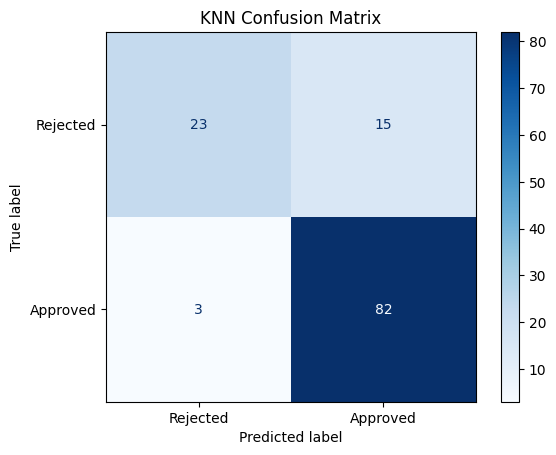

In [3]:
# ==========================================
# LOAN APPROVAL PREDICTION USING KNN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)

# ==========================================
# DROP LOAN ID
# ==========================================

df.drop("Loan_ID", axis=1, inplace=True)

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("\nFeatures:")
print(X.columns.tolist())

# ==========================================
# SPLIT DATASET (80/20)
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# STANDARDIZE FEATURES
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# HYPERPARAMETER TUNING
# ==========================================

k_values = range(1, 21)

best_k = 1
best_accuracy = 0

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print("\nBest K Value:", best_k)
print("Best Validation Accuracy:", round(best_accuracy * 100, 2), "%")

# ==========================================
# TRAIN FINAL MODEL
# ==========================================

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = final_knn.predict(X_test_scaled)

# ==========================================
# MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nKNN MODEL RESULTS")
print("=" * 40)

print("Accuracy:", round(accuracy * 100, 2), "%")

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ==========================================
# VISUALIZATION
# ==========================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.show()